# Figure 3: Spectrum overlay on the measured datasets with the calculated potential

This notebook computes the energy spectrum and transition structure
of the system as a function of phase, reproducing Fig. 3 of the paper.

Main steps:
1. Load and preprocess data
2. Construct Hamiltonian
3. Compute spectrum
4. Insert parameters
5. Plot results

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.constants as const
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec

from matplotlib.transforms import Bbox

## Constants and calibrational data

In [2]:
# ------------------ Physical constants ------------------
Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1
Delta_Al = 3.4e-4*e # J


# ------------------ System parameters ------------------
T = 15e-3 #K
Ec= 0.233e9*h #JAC
C = e**2/(2*Ec) #F

Ej = [38.844, 39.119, 40.903, 42.825, 45.982, 48.452, 47.903, 53.394, 53.394, 60.531, 57.649, 65.473, 61.080, 68.904, 67.257]  # GHz

jj_area = [380**2, 390**2, 400**2, 410**2, 420**2, 430**2, 440**2, 450**2, 460**2, 470**2, 480**2, 490**2, 500**2, 510**2, 520**2]  # nm^2

## Data loading and preprocessing

In [3]:
# ------------------ Data loading ------------------
dataset_0436 = xr.load_dataset("Data/Q2_DS_1/DS_1_Qubit_spec.hdf5")
dataset_0436_wide = xr.load_dataset("Data/Q2_DS_1/DS_1_Qubit_spec_wide.hdf5")

dataset_0424 = xr.load_dataset("Data/Q2_DS_2/DS_2_Qubit_spec.hdf5")
dataset_0424_wide = xr.load_dataset("Data/Q2_DS_2/DS_2_Qubit_spec_wide.hdf5")

dataset_0406 = xr.load_dataset("Data/Q2_DS_3/DS_3_Qubit_spec.hdf5")
dataset_0406_wide = xr.load_dataset("Data/Q2_DS_3/DS_3_Qubit_spec_wide.hdf5")

dataset_0395 = xr.load_dataset("Data/Q2_DS_4/DS_4_Qubit_spec.hdf5")
dataset_0395_wide = xr.load_dataset("Data/Q2_DS_4/DS_4_Qubit_spec_wide.hdf5")

In [4]:
# ------------------ Data preprocessing ------------------

def adjust_dataset(dataset, xvar='x0', yvar='x1', scale_eng=1.0, scale_freq=1.0, shift=0.0):

    ds = dataset.copy()

    # Scale x-axis variable
    if xvar in ds:
        ds[xvar] = ds[xvar] * scale_eng
    else:
        print(f" Variable '{xvar}' not found in dataset.")

    # Shift y-axis variable
    if yvar in ds:
        ds[yvar] = ds[yvar]*scale_freq + shift
    else:
        print(f" Variable '{yvar}' not found in dataset.")

    return ds

In [5]:
# ------------------ Apply adjustments ------------------

dataset_0436_adj = adjust_dataset(dataset_0436, scale_eng =1e-9, scale_freq = 1.0753,  shift=1.775)
dataset_0436_wide_adj = adjust_dataset(dataset_0436_wide, scale_eng =1e-9, scale_freq = 1.0753, shift=1.775)

dataset_0424_adj = adjust_dataset(dataset_0424, scale_eng =1e-9, scale_freq = 1.0753, shift=1.77631)
dataset_0424_wide_adj = adjust_dataset(dataset_0424_wide, scale_eng =1e-9, scale_freq = 1.0753, shift=1.77631)

dataset_0406_adj = adjust_dataset(dataset_0406, scale_eng =1e-9, scale_freq = 1.0753, shift=1.778)
dataset_0406_wide_adj = adjust_dataset(dataset_0406_wide, scale_eng =1e-9, scale_freq = 1.0753, shift=1.778)

dataset_0395_adj = adjust_dataset(dataset_0395, scale_eng =1e-9, scale_freq = 1.0753, shift=1.7788)
dataset_0395_wide_adj = adjust_dataset(dataset_0395_wide, scale_eng =1e-9, scale_freq = 1.0753, shift=1.7788)

## Hamiltonian construction

In [6]:
# ------------------ Hamiltonian construction ------------------

def build_phase_hamiltonians(
        EJ1: float,
        EJ2: float,
        EJ3: float,
        EJ4: float,
        EJ5: float,
        flux1: np.ndarray,
        flux2: float,
        phis: np.ndarray,
        Ec: float,
        ng: float,
) -> np.ndarray:

    """
    Construct phase-basis Hamiltonians for a superconducting circuit.
    """
    # ----------------- Phase grid -----------------
    phis = phis * 2*np.pi
    N = len(phis)
    delta_phi = phis[1] - phis[0]

    # ----------------- Differential operators -----------------
        # First derivative
    D1 = np.eye(N,k=1) - np.eye(N,k=-1)
    D1[0,-1] = -1
    D1[-1,0] = 1
    D1 /= (2*delta_phi)

    # Second derivative (Laplacian)
    D2 = -2*np.eye(N) + np.eye(N,k=1) + np.eye(N,k=-1)
    D2[0,-1] = D2[-1,0] = 1
    D2 /= delta_phi**2

    # ----------------- Kinetic term -----------------
    T = 4*Ec * (-D2 + 2j*ng*D1 + ng**2*np.eye(N))
    
    # ----------------- Effective left arm SQUID parameters -----------------
    d = abs(EJ4 - EJ5)/abs(EJ4 + EJ5)
    EJsum = EJ4 + EJ5

    EJ45eff =  EJsum * np.sqrt((np.cos(np.pi*flux2))**2 + d**2*(np.sin(np.pi*flux2))**2)

    # Transmission coefficients (clipped for stability)
    t1 =  4*EJ1 *EJ2/(EJ1 + EJ2)**2
    t1 = np.clip(t1, 0.0, 1.0)

    t2 =  4*EJ3 *EJ45eff/(EJ3 + EJ45eff)**2
    t2 = np.clip(t2, 0.0, 1.0)

    # ----------------- Capacitances & charging energies for internal modes -----------------

    CJ1 = get_CJ(EJ1)
    CJ2 = get_CJ(EJ2)
    CJ3 = get_CJ(EJ3)
    CJ45 = get_CJ(EJ4) + get_CJ(EJ5)

    C_mod_L = CJ1 + CJ2
    EC_mod_L = e**2/(2*C_mod_L*h)*1e-9

    C_mod_R = CJ3 + CJ45
    EC_mod_R = e**2/(2*C_mod_R*h)*1e-9

    # ----------------- Energy scales -----------------
    E_L = EJ1 + EJ2
    E_R = EJ3 + EJ45eff

    # ----------------- Grid reshaping -----------------
    phi_grid = phis[None, :]                  # shape (1, N)
    flux1_grid = flux1[:, None] 

    V = np.zeros((len(flux1), N, N), dtype=float)

    # ----------------- Potential energy prefactors -----------------
    PF_L = np.sqrt(1 - t1 * np.sin((phi_grid)/2)**2)
    PF_L -= np.sqrt(2*EC_mod_L/E_L  * np.sqrt(1 - t1 * np.sin(phi_grid/2)**2))

    PF_R = np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2)
    PF_R -= np.sqrt(2*EC_mod_R/E_R  * np.sqrt(1 - t2 * np.sin((phi_grid - 2*np.pi*flux1_grid)/2)**2))

    # ----------------- Potential energy -----------------
    V_phi = -(E_L * PF_L + E_R * PF_R)

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])  

    # ----------------- Full Hamiltonian -----------------
    H_all = V + T[None, :, :] 

    return H_all, V_phi, phis


In [7]:
a, b = np.polyfit(jj_area, Ej, 1)

def get_junction_area(Ej):
    area = (Ej-b)/a
    return area

def get_CJ(EJ1):
    C_per_Area = 50e-15 #50 fF/mum^2
    
    area_EJ1 = get_junction_area(EJ1)*1e-6
    CJ1 =  C_per_Area*area_EJ1
    
    return CJ1

## Spectrum computation

In [8]:
# ------------------ Spectrum computation ------------------

def compute_spectrum(EJ1, EJ2, EJ3, EJ4, EJ5, EC, flux2, build_func, transitions,
                     phi_range=(0.5,0.6), phi_points=250, 
        f_res = 5.23):
    """
    Computes eigenvalues and selected transitions for a given flux2.
    """
    flux1 = np.linspace(*phi_range, phi_points)
    H_all, _, _ = build_func(EJ1, EJ2, EJ3, EJ4, EJ5,
                             flux1=flux1, flux2=flux2, phis=phi,
                             Ec=EC, ng=ng)
    eigvals, _ = np.linalg.eigh(H_all)
    
    f_trans = {}
    for i in range(eigvals.shape[1]):
        for j in range(i):
            key = f"f{j}{i}"
            f_trans[key] = eigvals[:, i] - eigvals[:, j]

    # Add detuning transitions if needed
    if f_res is not None:
        for t in transitions:
            if t.endswith("-res"):
                base = t[:-4]
                if base in f_trans:
                    f_trans[t] = f_trans[base] - f_res


    return flux1, f_trans

def compute_spectrum_potential(flux1_value, flux2_value):
    """
    Precompute potential + eigenstates for a given flux1, flux2.
    """
    H_all, V_psi, phis = build_phase_hamiltonians(
        EJ1=EJ1, EJ2=EJ2, EJ3=EJ3, EJ4=EJ4, EJ5=EJ5,
        phis=phi,
        flux1=np.array([flux1_value]),
        flux2=flux2_value,
        Ec=EC, ng=ng
    )

    H = H_all[0]
    H = (H + H.conj().T)/2  # Hermitian
    evals, evecs = np.linalg.eigh(H)
    evals = np.real(evals)
    
    phis = phis / (2*np.pi)
    psi_scale = 0.6* np.abs(evals).max() / dim

    return phis, evals, evecs, V_psi, psi_scale


## Plotting functions

In [9]:
def get_dataframes(dataset_entry):
    """
    Converts dataset dictionaries into df1, df2 suitable for plotting.
    """
    df1 = pd.DataFrame({
        'x': dataset_entry['dataset_narrow']['x1'].values,
        'y': dataset_entry['dataset_narrow']['x0'].values,
        'z': dataset_entry['dataset_narrow']['y0'].values
    })
    df2 = pd.DataFrame({
        'x': dataset_entry['dataset_wide']['x1'].values,
        'y': dataset_entry['dataset_wide']['x0'].values,
        'z': dataset_entry['dataset_wide']['y0'].values
    })
    return df1, df2



In [10]:
# ------------------ Plotting utilities ------------------

def plot_two_datasets_with_theory_ax(df1, df2,
                                     EJ1, EJ2, EJ3, EJ4, EJ5, EC, flux2,
                                     build_func=None,
                                     ax=None,
                                     rescale=1, rescale_w=1,
                                     vmax=None, vmax_w=None,
                                     xscale1=1, xscale2=1,
                                     cmap1='Blues', cmap2='Blues',
                                     vmin=None,
                                     **kwargs):
    """
    Plots narrow and wide datasets on the same axis.
    """
    if ax is None:
        fig, ax = plt.subplots()
    
    def reshape_df(df):
        x_unique = np.unique(df['x'])
        y_unique = np.unique(df['y'])
        X, Y = np.meshgrid(y_unique, x_unique)
        Z = df['z'].values.reshape(len(x_unique), len(y_unique))
        return X, Y, Z
    
    X1, Y1, Z1 = reshape_df(df1)
    X2, Y2, Z2 = reshape_df(df2)
    

    # Normalize each
    Z1 = (Z1 - np.min(Z1)) / (np.max(Z1) - np.min(Z1))
    Z2 = (Z2 - np.min(Z2)) / (np.max(Z2) - np.min(Z2))

    Z1 = Z1 * rescale
    Z2 = Z2 * rescale_w

# Unified colorbar range
    vmax_global = max(vmax if vmax else 1, vmax_w if vmax_w else 1)
    # -------------------------------------------------------------
    # BASE PLOT
    # -------------------------------------------------------------
    mesh1 = ax.pcolormesh(Y2 * xscale2, X2, Z2,
                          shading='auto', cmap=cmap2,
                          vmin=vmin, vmax=vmax_global, rasterized=True)

    mesh2 = ax.pcolormesh(Y1 * xscale1, X1, Z1,
                          shading='auto', cmap=cmap1,
                          vmin=vmin, vmax=vmax_global, rasterized=True)
    
    return mesh1  # return one mesh for colorbar

def transition_label(t):
    """
    Convert transition key to LaTeX label.
    Examples:
      f01      -> $f_{01}$
      f12      -> $f_{12}$
      f03-res  -> $f_{03} - f_{\\mathrm{res}}$
    """
    if t.endswith('-res'):
        base = t[:-4]          # remove '-res'
        i, j = base[1], base[2]
        return rf'$f_{{{i}{j}}} - f_{{\mathrm{{res}}}}$'
    else:
        i, j = t[1], t[2]
        return rf'$f_{{{i}{j}}}$'


def plot_dataset(key, df1, df2, transitions_results, transitions_to_plot=None, ax=None,  cmap1='Blues', cmap2='Blues',):
    """
    Plot a dataset with selected transitions overlayed.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4,3))
    
    # Plot data
    mesh = plot_two_datasets_with_theory_ax(df1, df2,
                                            EJ1, EJ2, EJ3, EJ4, EJ5, EC,
                                            flux2=transitions_results[key]["flux2"],
                                            ax=ax,
                                            rescale=phi_2_datasets[key]['rescale'],
                                            rescale_w=phi_2_datasets[key]['rescale_w'],  cmap1=cmap1, cmap2=cmap2, )
    
    # Overlay cached transitions
    flux1 = transitions_results[key]["flux1"]
    f_trans = transitions_results[key]["transitions"]
    if transitions_to_plot is None:
        transitions_to_plot = f_trans.keys()
    

    for t in transitions_to_plot:
        if t not in f_trans:
            continue

        col = transition_colors.get(t, 'sienna')  # fallback color

        ls = '--' if '-res' in t else '-'
        lw = 0.9 if '-res' not in t else 0.8
        label = transition_label(t)

        ax.plot(flux1, f_trans[t], color=col, lw=lw, linestyle=ls, label = label)
    
    return mesh


def plot_phase_basis_stack_from_result(
    ax,
    result,
    title="",
    dashed_levels=None,
):
    """
    Plot potential + first 4 eigenstates from precomputed result
    using parity-consistent coloring.
    """

    phis = result["phis"]
    evals = result["evals"].copy()
    evecs = result["evecs"]
    V_psi = result["V_psi"]
    psi_scale = result["psi_scale"]

    if dashed_levels is None:
        dashed_levels = []

    # Shift energies
    E0 = evals[0]
    evals -= E0

    # Potential
    ax.plot(
        phis,
        V_psi[0, :] - E0,
        color="gray",
        lw=1.2,
        ls="--",
        label=r"$U(\varphi)$"
    )

    # Wavefunctions (parity coloring)
    for i in range(4):

        psi = (evecs[:, i])
        linestyle = "-." if i in dashed_levels else "-"

        if i % 2 == 0:  # even
            color = even_colors[i]
        else:           # odd
            color = odd_colors[i]

        ax.plot(
            phis,
            evals[i] + psi * psi_scale,
            lw=1.2,
            ls=linestyle,
            color=color,
            label=rf"$\psi_{i}$"
        )

    ax.set_title(title)


## System parameters

In [11]:
# ------------------------- System parameters -------------------------

phi = np.linspace(-0.5, 0.5, 251)
flux1 = np.linspace(0, 1, 51)

ncut = 50
dim = 2 * ncut + 1


EC = 0.21
EJ1 = 42.49
EJ2 = 53.9
EJ3 = 88.11
EJ4 = 35.73
EJ5 = 35.731
ng = 0




phi_2_datasets = {
    '1': {
        'dataset_narrow': dataset_0436_adj,
        'dataset_wide':   dataset_0436_wide_adj,
        'flux2': 0.406,
        'shift': 1.775,
        'rescale':  20,
        'rescale_w': 10
    },
    '2': {
        'dataset_narrow': dataset_0424_adj,
        'dataset_wide':   dataset_0424_wide_adj,
        'flux2': 0.395,
        'shift': 1.77631,
        'rescale':  35,
        'rescale_w': 3
    },
    '3': {
        'dataset_narrow': dataset_0406_adj,
        'dataset_wide':   dataset_0406_wide_adj,
        'flux2': 0.378,
        'shift': 1.778,
        'rescale':  5,
        'rescale_w': 5
    },
    '4': {
        'dataset_narrow': dataset_0395_adj,
        'dataset_wide':   dataset_0395_wide_adj,
        'flux2': 0.367,
        'shift': 1.7788,
        'rescale':  5,
        'rescale_w': 5
    }
}

dataset_keys = ['1', '2', '3', '4']

## Main computation

In [12]:
# --------------------------- Main computation ------------------

# ------------------------- Compute transitions -------------------------

transitions_per_dataset = {
    "1": ('f01','f02', 'f12',),
    "2": ('f01','f02', 'f03','f12',),
    "3": ('f01','f02', 'f03','f12',),
    "4": ('f01','f02', 'f03', 'f12')
}

transitions_results = {}
for key in phi_2_datasets:
    flux2 = phi_2_datasets[key]["flux2"]
    flux1, f_trans = compute_spectrum(EJ1, EJ2, EJ3, EJ4, EJ5, EC,
                                        flux2, build_phase_hamiltonians,
                                        transitions=transitions_per_dataset.get(key, ('f01','f02', 'f12', 'f02-res', 'f03-res', 'f13-res', 'f04-res', 'f15-res')))
    transitions_results[key] = {
        "flux1": flux1,
        "flux2": flux2,
        "transitions": f_trans
    }

# ------------------------- Compute potential -------------------------

dataset_keys_phase = dataset_keys[-2:]  # last two datasets
potential_results = {}

for key in dataset_keys_phase:
    flux2_value = phi_2_datasets[key]["flux2"]
    flux1_value = 0.5
    
    phis, evals, evecs, V_psi, psi_scale = compute_spectrum_potential(flux1_value, flux2_value)
    
    potential_results[key] = {  # key must exactly match dataset_keys_phase
        "flux1": flux1_value,
        "flux2": flux2_value,
        "phis": phis,
        "evals": evals,
        "evecs": evecs,
        "V_psi": V_psi,
        "psi_scale": psi_scale
    }


## Visualization

In [13]:
# ------------------ Plot styling ------------------

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})


even_cmap = mpl.colormaps['Oranges']
odd_cmap  = mpl.colormaps['Purples']

even_colors = {
    0: even_cmap(0.65),
    2: even_cmap(0.85),
}

odd_colors = {
    1: odd_cmap(0.65),
    3: odd_cmap(0.9),
}

transition_colors = {
    'f01': "#38610C",   
    'f02': "#65863F",
    'f12': "#64305C",
    'f03': "#8EAA70",


    # detuned transitions (optional)
    'f01-res': 'goldenrod',
    'f02-res': 'goldenrod',
    'f03-res': 'goldenrod',
    'f04-res': 'goldenrod',
}

markers = ['^','D', 's', 'o', ]  # triangle, circle, square, plus
marker_color = 'black'

c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


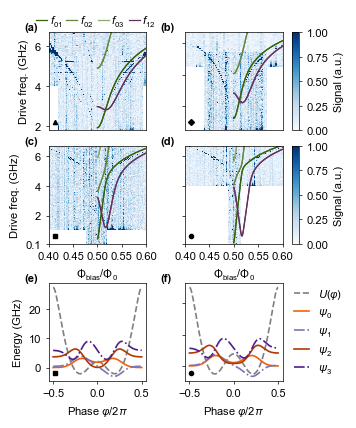

In [35]:
# -------------------------- Plot datasets + transitions -------------------------

# ------------------------- Figure setup -------------------------
fig = plt.figure()
fig.set_size_inches(3.40457, 4.1)
fig.subplots_adjust(top=0.94, bottom=0.09, right=0.86)

# ------- New GridSpec: 5 rows, with empty spacer rows ------
gs = gridspec.GridSpec(
    5, 5,
    width_ratios=[1, 0.15, 1, -0.15, 0.07],
    height_ratios=[1, -0.03, 1, 0.21, 1],  
    wspace=0.3,
    hspace=0.15
)


# Top spectroscopy (row 0)
ax11 = fig.add_subplot(gs[0,0])
ax12 = fig.add_subplot(gs[0,2])
cax_top = fig.add_subplot(gs[0,4])

# Bottom spectroscopy (row 2)  ← was row 1
ax21 = fig.add_subplot(gs[2,0])
ax22 = fig.add_subplot(gs[2,2])
cax_bottom = fig.add_subplot(gs[2,4])



axes_spec = [ax11, ax12, ax21, ax22]
mappable_top, mappable_bottom = None, None

for idx, (ax, key) in enumerate(zip(axes_spec, dataset_keys)):
    df1, df2 = get_dataframes(phi_2_datasets[key])
    hm = plot_dataset(key, df1, df2, transitions_results,
                      transitions_to_plot=transitions_per_dataset.get(key),
                      ax=ax)
    if idx < 2 and mappable_top is None:
        mappable_top = hm
    elif idx >=2 and mappable_bottom is None:
        mappable_bottom = hm

for idx, (ax, key) in enumerate(zip(axes_spec, dataset_keys)):
    df1, df2 = get_dataframes(phi_2_datasets[key])
    hm = plot_dataset(key, df1, df2, transitions_results,
                      transitions_to_plot=transitions_per_dataset.get(key),
                      ax=ax)
    
    # Add resonator line if f_res is defined
    f_res = phi_2_datasets[key].get("f_res", None)
    if f_res is not None:
        ax.axhline(f_res, color='tab:olive', ls='--', lw=1.5, alpha=0.8)

    # Adjust layout + ticks

    ax.set_xlim(0.4, 0.6)
    ax.set_xticks(np.arange(0.4, 0.61, 0.05))
    ax.set_ylim(min(df1['y'].min(), df2['y'].min()), 6.698)

top_ticks = [ 2, 4, 6]

# Left column
ax11.set_yticks(top_ticks)
ax11.set_yticklabels(top_ticks)  # show labels
ax11.yaxis.set_tick_params(labelleft=True)

# Right column: same ticks, but hide labels
ax12.set_yticks(top_ticks)
ax12.set_yticklabels([])         # hide labels
ax12.yaxis.set_tick_params(labelleft=False)

# ------------------------- Custom y-ticks for second row -------------------------

bottom_ticks = [0.1, 2, 4, 6]

# Left column
ax21.set_yticks(bottom_ticks)
ax21.set_yticklabels(bottom_ticks)  # show labels
ax21.yaxis.set_tick_params(labelleft=True)

# Right column: same ticks, but hide labels
ax22.set_yticks(bottom_ticks)
ax22.set_yticklabels([])            # hide labels
ax22.yaxis.set_tick_params(labelleft=False)

for idx, ax in enumerate(axes_spec):
    ax.plot(
        0.06, 0.08,                    # position in axes coordinates
        marker=markers[idx],
        color=marker_color,
        markersize=3,
        linestyle='None',
        transform=ax.transAxes,
        zorder=20,
        clip_on=False
    )
    
ax11.set_ylabel(r"Drive freq. (GHz)")
ax21.set_ylabel(r"Drive freq. (GHz)")
ax11.set_xticks([])
ax12.set_xticks([])
ax21.set_xlabel(r"$\Phi_{\mathrm{bias}}/\Phi_0$")
ax22.set_xlabel(r"$\Phi_{\mathrm{bias}}/\Phi_0$")
plt.colorbar(mappable_top, cax=cax_top, label="Signal (a.u.)")
plt.colorbar(mappable_bottom, cax=cax_bottom, label="Signal (a.u.)")

# Phase maps (row 4)
ax_e = fig.add_subplot(gs[4,0])
ax_f = fig.add_subplot(gs[4,2])


# Left panel
key_e = str(dataset_keys_phase[0])
plot_phase_basis_stack_from_result(
    ax_e,
    potential_results[key_e],
     dashed_levels=[1, 3]
)

ax_e.set_xlabel(r"Phase $\varphi / 2\pi$")
ax_e.set_ylabel("Energy (GHz)")
# Right panel
key_f = str(dataset_keys_phase[1])
plot_phase_basis_stack_from_result(
    ax_f,
    potential_results[key_f],
    dashed_levels=[1,3]
)
ax_f.set_xlabel(r"Phase $\varphi / 2\pi$")
# Hide y-axis labels for right panel
ax_f.set_yticklabels([])
ax_f.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    handlelength=1.3,
    frameon=False,
    fontsize=8
)

bottom_axes = [ax_e, ax_f]
bottom_markers = markers[-2:]   # ['s', '+']

for ax, m in zip(bottom_axes, bottom_markers):
    ax.plot(
        0.06, 0.08,
        marker=m,
        color=marker_color,
        markersize=3,
        linestyle='None',
        transform=ax.transAxes,
        zorder=20,
        clip_on=False
    )


# Union of Pot A and Pot B positions (in figure coords)
bbox = Bbox.union([
    ax11.get_position(),
    ax12.get_position(),
])

handles, labels = ax22.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # keeps only the first occurrence of each label

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    fontsize=8,
    bbox_to_anchor=(bbox.x0 + bbox.width/2 -0.205, bbox.y1 +0.07),
    bbox_transform=fig.transFigure,
    ncol=len(by_label),   # use number of unique labels
    frameon=False,
    handlelength=1,
    columnspacing=0.4,
    handletextpad=0.2,
)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, label in zip([ax11, ax12, ax21, ax22, ax_e, ax_f], panel_labels):
    ax.text(-0.25, 1.1, label, transform=ax.transAxes,
            fontweight='bold', va='top')

fig.savefig("Fig3_Transitions.pdf", dpi=1200)

plt.show()
